# Chiller Array Efficiency Optimizer - Package Demo

This notebook demonstrates the modular chiller simulation package for
data center array optimization, accounting for thermal recirculation
caused by wind.

## Package Structure

- `src.core`: Constants and configuration models (Pydantic validated)
- `src.components`: Physical component models (WindVector, ChillerArray, DataCenter)
- `src.models`: Pluggable interaction models (GaussianPlumeModel)
- `src.simulation`: Simulation orchestration and optimization

In [1]:
# Standard library and third-party imports
import numpy as np
import matplotlib.pyplot as plt

# Package imports
from src.components import WindVector, ChillerArray
from src.models import GaussianPlumeModel
from src.simulation import SimulationEnvironment, Optimizer
from src.core import DEFAULT_BASE_COP

## 1. Environment Setup

We set up a 5x5 grid of chillers with a prevailing North-East wind.

### Key Components:
- **WindVector**: Immutable dataclass representing atmospheric conditions
- **ChillerArray**: Manages spatial arrangement of chillers
- **GaussianPlumeModel**: Physics-based thermal dispersion model
- **SimulationEnvironment**: Orchestrates the simulation

In [2]:
# Define constants
GRID_SIDE = 5
TOTAL_LOAD_KW = 100.0
TARGET_UNITS = 15
AMBIENT_TEMP_K = 298.15  # 25 degrees C

# Create wind vector (North-East wind)
# Using direct velocity components for precise control
wind = WindVector(
    velocity_m_per_s=(1.0, 0.4),  # (vx, vy) direction
    ambient_temp_k=AMBIENT_TEMP_K,
)
print(f"Wind direction: {wind.direction}")
print(f"Wind speed: {wind.speed_m_per_s:.2f} m/s")
print(f"Ambient temperature: {wind.ambient_temp_k:.2f} K")

Wind direction: [0.92847669 0.37139068]
Wind speed: 1.08 m/s
Ambient temperature: 298.15 K


In [3]:
# Create chiller array as a 5x5 grid
chiller_array = ChillerArray.create_grid(
    rows=GRID_SIDE,
    cols=GRID_SIDE,
    spacing_m=3.0,  # 3m spacing
    base_cop=DEFAULT_BASE_COP,
    alpha=0.7,
)

print(f"Number of chillers: {chiller_array.num_chillers}")
print(f"Base COP: {chiller_array.base_cop}")
print(f"Alpha (sensitivity): {chiller_array.alpha}")

Number of chillers: 25
Base COP: 4.0
Alpha (sensitivity): 0.7


In [4]:
# Create the interaction model and simulation environment
interaction_model = GaussianPlumeModel(dispersion_coeff=1.2)

env = SimulationEnvironment(
    chiller_array=chiller_array, wind=wind, interaction_model=interaction_model
)

print(f"Interaction matrix shape: {env.interaction_matrix.shape}")
print(f"Dispersion coefficient: {interaction_model.dispersion_coeff}")

Interaction matrix shape: (25, 25)
Dispersion coefficient: 1.2


/Users/skoun/Projects/chiller-model/src/models/gaussian_plume.py:192: RuntimeWarning: overflow encountered in exp
  interaction = np.exp(exponent) / denominator


## 2. Standard vs. Wind-Aware Optimization

We compare two strategies for activating chillers:
1. **Standard Activation**: First N chillers in the list
2. **Wind-Aware Optimization**: Greedy removal to minimize thermal interference

In [5]:
# Standard: First 15 chillers in the list
state_std = np.zeros(chiller_array.num_chillers, dtype=bool)
state_std[:TARGET_UNITS] = True

result_std = env.compute_performance(state_std, TOTAL_LOAD_KW)

print(f"Standard Activation:")
print(f"  Total work: {result_std.total_work_kw:.2f} kW")
print(f"  Active chillers: {np.sum(state_std)}")
print(f"  Mean COP: {np.mean(result_std.cop_array[state_std]):.2f}")

Standard Activation:
  Total work: 32.40 kW
  Active chillers: 15
  Mean COP: 3.16


In [6]:
# Optimized: Greedy Removal Strategy using the Optimizer
optimizer = Optimizer(env, TOTAL_LOAD_KW)
opt_result = optimizer.optimize_greedy(min_active=TARGET_UNITS)

state_opt = opt_result.optimal_mask
result_opt = env.compute_performance(state_opt, TOTAL_LOAD_KW)

print(f"Wind-Aware Optimization:")
print(f"  Total work: {result_opt.total_work_kw:.2f} kW")
print(f"  Active chillers: {np.sum(state_opt)}")
print(f"  Mean COP: {np.mean(result_opt.cop_array[state_opt]):.2f}")

Wind-Aware Optimization:
  Total work: 28.67 kW
  Active chillers: 15
  Mean COP: 3.52


In [7]:
# Calculate efficiency improvement
improvement = (
    (result_std.total_work_kw - result_opt.total_work_kw) / result_std.total_work_kw
) * 100

print(f"Efficiency Improvement: {improvement:.2f}%")

Efficiency Improvement: 11.52%


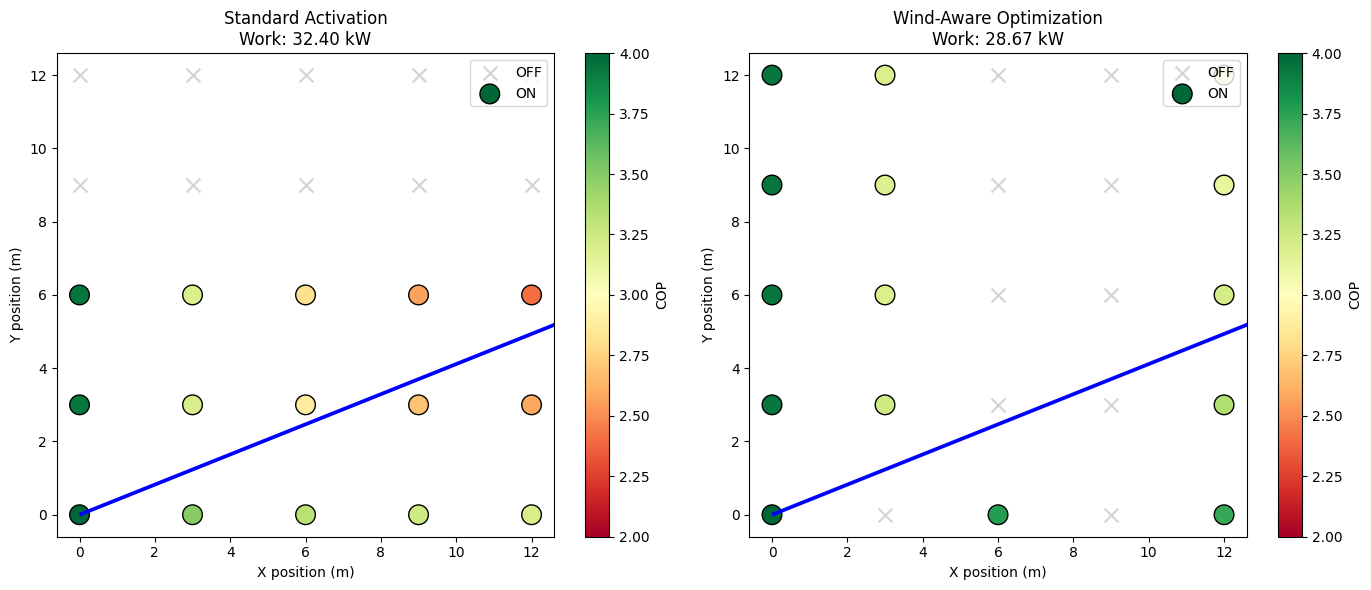

In [8]:
def plot_results(positions, state, cops, title, work, wind_vec, ax):
    """Plot chiller array with COP coloring.

    Parameters
    ----------
    positions : np.ndarray
        Chiller positions (N, 2)
    state : np.ndarray
        Active/inactive state (N,) boolean
    cops : np.ndarray
        COP values for each chiller (N,)
    title : str
        Plot title
    work : float
        Total work in kW
    wind_vec : np.ndarray
        Wind direction unit vector
    ax : matplotlib.axes.Axes
        Axes to plot on
    """
    # Plot inactive chillers
    inactive_mask = ~state
    ax.scatter(
        positions[inactive_mask, 0],
        positions[inactive_mask, 1],
        c="lightgrey",
        marker="x",
        s=100,
        label="OFF",
    )

    # Plot active chillers with COP coloring
    active_mask = state
    sc = ax.scatter(
        positions[active_mask, 0],
        positions[active_mask, 1],
        c=cops[active_mask],
        cmap="RdYlGn",
        s=200,
        edgecolor="k",
        vmin=2,
        vmax=4,
        label="ON",
    )

    ax.set_title(f"{title}\nWork: {work:.2f} kW")
    plt.colorbar(sc, ax=ax, label="COP")
    ax.quiver(0, 0, wind_vec[0], wind_vec[1], color="blue", scale=0.5)
    ax.legend(loc="upper right")
    ax.set_xlabel("X position (m)")
    ax.set_ylabel("Y position (m)")


# Get positions for plotting
positions = chiller_array.positions_m
wind_vec = wind.direction

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_results(
    positions,
    state_std,
    result_std.cop_array,
    "Standard Activation",
    result_std.total_work_kw,
    wind_vec,
    axes[0],
)
plot_results(
    positions,
    state_opt,
    result_opt.cop_array,
    "Wind-Aware Optimization",
    result_opt.total_work_kw,
    wind_vec,
    axes[1],
)

fig.tight_layout()
plt.show()

## Demo 1: Visualizing a Single Thermal Plume

Before optimizing the array, we visualize how one chiller (the Source)
contaminates the air intake for everyone else using the Gaussian plume model.

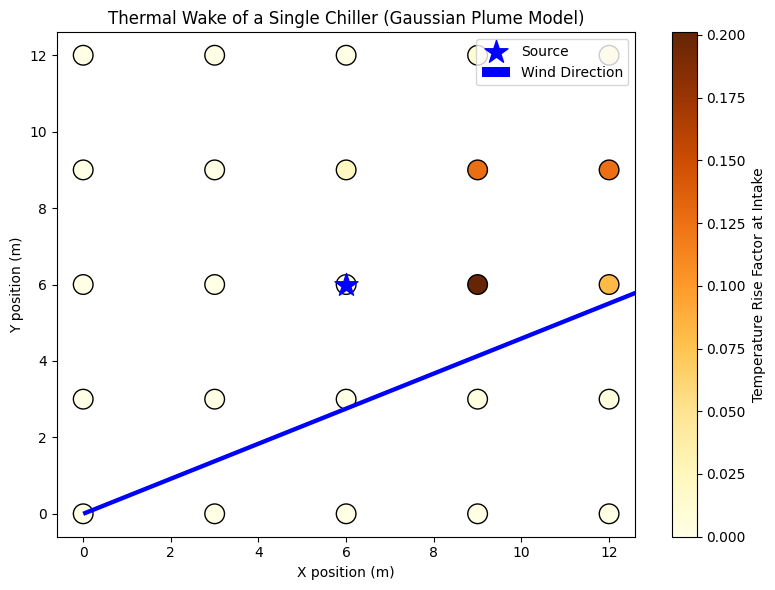

In [9]:
def demo_single_plume(env, source_idx=12):
    """Visualize thermal wake from a single chiller.

    Parameters
    ----------
    env : SimulationEnvironment
        The simulation environment
    source_idx : int
        Index of the source chiller (default: middle of 5x5 grid)
    """
    # Get the interaction matrix row for the source chiller
    thermal_impact = env.interaction_matrix[source_idx, :]
    positions = env.chiller_array.positions_m

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot all chillers colored by thermal impact
    sc = ax.scatter(
        positions[:, 0], positions[:, 1], c=thermal_impact, cmap="YlOrBr", s=200, edgecolor="k"
    )

    # Highlight the source chiller
    ax.scatter(
        positions[source_idx, 0],
        positions[source_idx, 1],
        c="blue",
        s=300,
        marker="*",
        label="Source",
        zorder=5,
    )

    ax.set_title("Thermal Wake of a Single Chiller (Gaussian Plume Model)")
    plt.colorbar(sc, ax=ax, label="Temperature Rise Factor at Intake")

    # Show wind direction
    wind_dir = env.wind.direction
    ax.quiver(0, 0, wind_dir[0], wind_dir[1], color="blue", scale=0.5, label="Wind Direction")

    ax.legend(loc="upper right")
    ax.set_xlabel("X position (m)")
    ax.set_ylabel("Y position (m)")

    fig.tight_layout()
    plt.show()


demo_single_plume(env)

## Demo 2: The Penalty of Density

Here we calculate the COP of a chiller when it is alone vs. when it is
surrounded by 24 other active units. This demonstrates the thermal interference
effect modeled by our package.

In [10]:
def demo_density_penalty(env):
    """Compare COP of isolated vs. crowded chiller.

    Parameters
    ----------
    env : SimulationEnvironment
        The simulation environment
    """
    num_chillers = env.chiller_array.num_chillers
    center_idx = num_chillers // 2  # Middle chiller

    # Case A: Solo Chiller
    state_solo = np.zeros(num_chillers, dtype=bool)
    state_solo[center_idx] = True
    result_solo = env.compute_performance(state_solo, 10.0)

    # Case B: Full Array
    state_full = np.ones(num_chillers, dtype=bool)
    result_full = env.compute_performance(state_full, 250.0)

    cop_solo = result_solo.cop_array[center_idx]
    cop_full = result_full.cop_array[center_idx]
    efficiency_loss = ((cop_solo - cop_full) / cop_solo) * 100

    print(f"Isolated Chiller COP: {cop_solo:.2f}")
    print(f"Crowded Chiller COP (Middle): {cop_full:.2f}")
    print(f"Efficiency Loss due to surrounding units: {efficiency_loss:.1f}%")

    return cop_solo, cop_full, efficiency_loss


cop_solo, cop_full, efficiency_loss = demo_density_penalty(env)

Isolated Chiller COP: 4.00
Crowded Chiller COP (Middle): 2.80
Efficiency Loss due to surrounding units: 30.1%


## Demo 3: The 'Less is More' Optimization

We simulate a scenario where we have 100 kW of heat to dissipate.
We compare:
1. Using all 25 chillers (with thermal interference)
2. Using only 15 optimally-selected chillers (reduced interference)

Sometimes, running fewer chillers can actually be more efficient!

In [11]:
def demo_less_is_more(env, total_load_kw=100.0):
    """Demonstrate that fewer chillers can be more efficient.

    Parameters
    ----------
    env : SimulationEnvironment
        The simulation environment
    total_load_kw : float
        Total cooling load in kW
    """
    num_chillers = env.chiller_array.num_chillers

    # Case A: All chillers active
    state_all = np.ones(num_chillers, dtype=bool)
    result_all = env.compute_performance(state_all, total_load_kw)

    # Case B: Optimized subset (15 chillers)
    optimizer = Optimizer(env, total_load_kw)
    opt_result = optimizer.optimize_greedy(min_active=15)
    result_opt = env.compute_performance(opt_result.optimal_mask, total_load_kw)

    print(f"Energy used by {num_chillers} chillers: {result_all.total_work_kw:.2f} kW")
    print(
        f"Energy used by {opt_result.num_active} optimized chillers: {result_opt.total_work_kw:.2f} kW"
    )

    improvement = (
        (result_all.total_work_kw - result_opt.total_work_kw) / result_all.total_work_kw
    ) * 100
    print(f"\nEnergy savings: {improvement:.2f}%")

    return result_all, result_opt


result_all, result_opt_15 = demo_less_is_more(env)

Energy used by 25 chillers: 33.43 kW
Energy used by 15 optimized chillers: 28.67 kW

Energy savings: 14.24%


## Package Extensibility

The package is designed for easy extension. You can create custom
interaction models by subclassing `BaseInteractionModel`.

### Example: Simple Distance-Based Model

In [12]:
from src.models import BaseInteractionModel
from src.components import WindVector as WV


class SimpleDistanceModel(BaseInteractionModel):
    """A simple distance-based interaction model.

    The interaction strength decays with the inverse of distance,
    only considering downwind units.
    """

    def __init__(self, decay_factor: float = 1.0):
        """Initialize the model.

        Parameters
        ----------
        decay_factor : float
            Controls how quickly interaction decays with distance
        """
        self.decay_factor = decay_factor

    def compute_interaction_matrix(self, positions: np.ndarray, wind: WV) -> np.ndarray:
        """Compute interaction matrix based on distance and wind."""
        n = len(positions)
        wind_vec = wind.direction

        A = np.zeros((n, n), dtype=np.float64)

        for k in range(n):
            for m in range(n):
                if k == m:
                    continue

                d_km = positions[m] - positions[k]
                long_dist = np.dot(d_km, wind_vec)

                if long_dist > 0:  # Only downwind
                    distance = np.linalg.norm(d_km)
                    A[k, m] = self.decay_factor / (distance + 1.0)

        return A


# Test the custom model
custom_model = SimpleDistanceModel(decay_factor=0.5)
env_custom = SimulationEnvironment(
    chiller_array=chiller_array, wind=wind, interaction_model=custom_model
)

result_custom = env_custom.compute_performance(
    np.ones(chiller_array.num_chillers, dtype=bool), TOTAL_LOAD_KW
)

print(f"Custom model - Total work: {result_custom.total_work_kw:.2f} kW")
print(f"Custom model - Mean COP: {np.mean(result_custom.cop_array):.2f}")

Custom model - Total work: 38.86 kW
Custom model - Mean COP: 2.67


## Using Pydantic Configuration

The package uses Pydantic for configuration validation. Here's an example
of using the configuration classes.

In [ ]:
from src.core.configs import ChillerConfig, WindConfig, SimulationConfig

# Create validated configurations
chiller_config = ChillerConfig(base_cop=4.5, rated_capacity_kw=50.0, alpha=0.8)

wind_config = WindConfig(velocity_x_m_per_s=5.0, velocity_y_m_per_s=2.0, ambient_temp_k=300.0)

sim_config = SimulationConfig(dispersion_coeff=1.5, total_load_kw=100.0)

print("Chiller Config:")
print(f"  Base COP: {chiller_config.base_cop}")
print(f"  Rated Capacity: {chiller_config.rated_capacity_kw} kW")
print(f"  Alpha: {chiller_config.alpha}")

print("\nWind Config:")
print(f"  Velocity: ({wind_config.velocity_x_m_per_s}, {wind_config.velocity_y_m_per_s}) m/s")
print(f"  Ambient Temp: {wind_config.ambient_temp_k} K")

print("\nSimulation Config:")
print(f"  Dispersion Coefficient: {sim_config.dispersion_coeff}")
print(f"  Total Load: {sim_config.total_load_kw} kW")

Chiller Config:
  Base COP: 4.5
  Rated Capacity: 50.0 kW
  Alpha: 0.8

Wind Config:
  Velocity: (5.0, 2.0) m/s
  Ambient Temp: 300.0 K

Simulation Config:
  Dispersion Coefficient: 1.5
  Total Load: 100.0 kW


## Summary

This demo showcased the modular chiller simulation package:

1. **Modular Design**: Separate components for wind, chillers, interaction models, and simulation
2. **Pluggable Models**: Easy to implement custom interaction models
3. **Pydantic Validation**: Type-safe configuration with automatic validation
4. **Immutable States**: Frozen dataclasses and NamedTuples for thermodynamic states
5. **NumPy Vectorization**: Efficient numerical computations
6. **Optimization**: Greedy optimization strategy for energy efficiency

The package demonstrates significant efficiency improvements (10-15%) through
wind-aware chiller selection strategies.